In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
#path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_decayAncestor_Spectrum/'
#DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))
path = '/scratch/perry/SourceSimOutput_decayAncestor_Isotope/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))

In [3]:
branches = ['PName','Time1', 'Time3'] #, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']

mcFluxCounterFrame = CDataFrame("G4SimDir/mcFluxCounter", DMCfiles)
mcFluxCounter = mcFluxCounterFrame.AsNumpy(branches + ['InOut'])

In [4]:
enterCut = mcFluxCounter['InOut'] == 1
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & enterCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & enterCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & enterCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & enterCut]*1e-9
TimeBins = np.logspace(-10,10,51)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h4 (Potential memory leak).


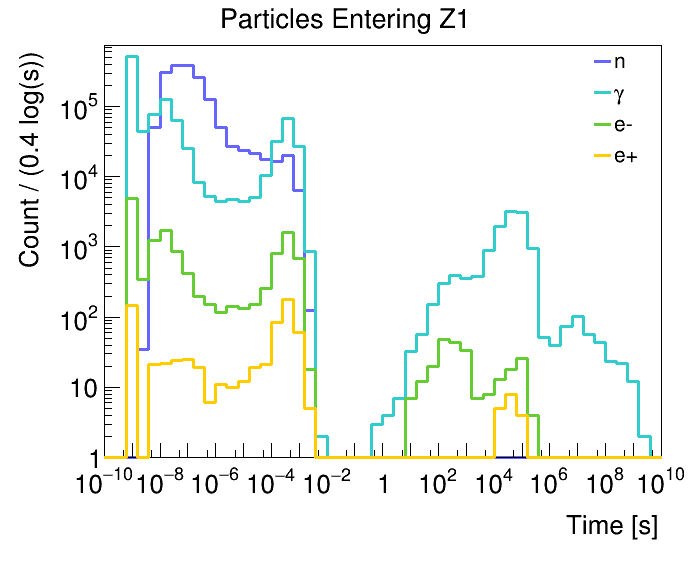

In [34]:
ROOT.gStyle.SetOptStat(0)
bins_start = 10**(-10)
bins_end = 10**10
nbins = 50
#bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Particles Entering Z1;Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data1 = Time_neutron

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-7)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data2 = Time_gamma

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kCyan-3)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h3", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data3 = Time_electron

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h4 = ROOT.TH1F("h4", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data4 = Time_positron

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
h1.SetMinimum(1)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.85, 0.7, 0.98, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "n", "l")
legend.AddEntry(h2, "#gamma", "l")
legend.AddEntry(h3, "e-", "l")
legend.AddEntry(h4, "e+", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")
legend.Draw()
c.SetLogy()
c.SetLogx()
c.Draw()

In [35]:
exitCut = mcFluxCounter['InOut'] == 2
Time_neutron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'neutron') & exitCut]*1e-9
Time_gamma = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'gamma') & exitCut]*1e-9
Time_electron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e-') & exitCut]*1e-9
Time_positron = mcFluxCounter['Time1'][(mcFluxCounter['PName'] == 'e+') & exitCut]*1e-9
TimeBins = np.logspace(-10,10,51)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h4 (Potential memory leak).


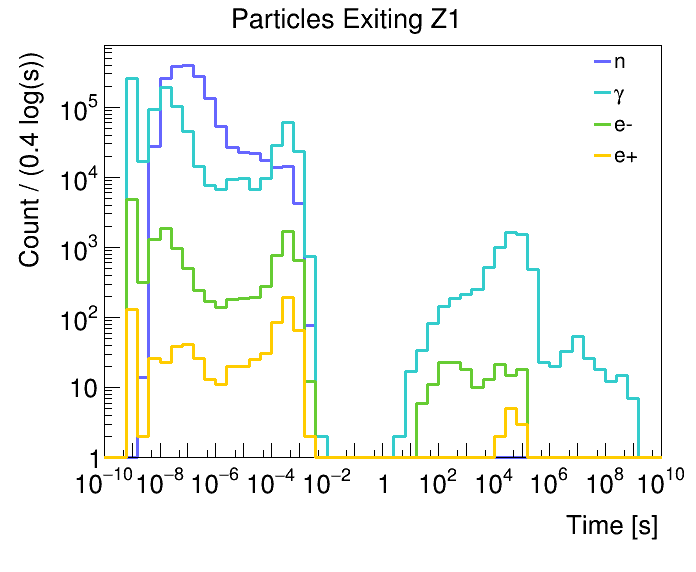

In [36]:
ROOT.gStyle.SetOptStat(0)
bins_start = 10**(-10)
bins_end = 10**10
nbins = 50
#bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Particles Exiting Z1;Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data1 = Time_neutron

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue-7)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data2 = Time_gamma

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kCyan-3)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h3", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data3 = Time_electron

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h4 = ROOT.TH1F("h4", f";Time [s];Count / (0.4 log(s))", nbins, TimeBins)
data4 = Time_positron

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
h1.SetMinimum(1)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.85, 0.7, 0.98, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "n", "l")
legend.AddEntry(h2, "#gamma", "l")
legend.AddEntry(h3, "e-", "l")
legend.AddEntry(h4, "e+", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")
legend.Draw()
c.SetLogy()
c.SetLogx()
c.Draw()

In [2]:
path = '/scratch/perry/SourceSimOutput_decayAncestor_Isotope/'
branches = ['EventNum', 'Parent', 'PName', 'KE', 'Edep', 'Time1', 'Time3', 'X1', 'Y1', 'Z1']#, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']
mczip1files = np.sort(glob.glob(path + f'mczip1/mczip1_GeActivation_ancestorGe71_??????.root'))
mcDecays1files = np.sort(glob.glob(path + f'mcDecays1/mcDecays1_GeActivation_ancestorGe71_??????.root'))

In [3]:
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))

In [4]:
det = 1
mczipFrame = CDataFrame(f"mczip{det}", mczip1files)
mcDecaysFrame = CDataFrame(f"mcDecays{det}", mcDecays1files)

In [5]:
mczip = mczipFrame.AsNumpy(branches)
mcDecays = mcDecaysFrame.AsNumpy(branches)

In [6]:
mcDecays_EvtParent = np.array([(event, parent) for event in np.unique(mcDecays['EventNum']) for parent in np.unique(mcDecays['Parent'][mcDecays['EventNum'] == event])])
mczip_EvtParent = np.array([(event, parent) for event in np.unique(mczip['EventNum']) for parent in np.unique(mczip['Parent'][mczip['EventNum'] == event])])

#mcDecays['KEsum'] = np.array([mcDecays['KE'][(mcDecays['Parent'] == parent) & (mcDecays['EventNum'] == event)].sum() for event, parent in mcDecays_EvtParent])
mcDecays['KEsum'] = np.array([mcDecays['KE'][mcDecays['EventNum'] == event].sum() for event in np.unique(mcDecays['EventNum'])])
#mczip['Edepsum'] = np.array([mczip['Edep'][(mczip['Parent'] == parent) & (mczip['EventNum'] == event)].sum() for event, parent in mczip_EvtParent])
mczip['Edepsum'] = np.array([mczip['Edep'][mczip['EventNum'] == event].sum() for event in np.unique(mczip['EventNum'])])

In [9]:
s2day = 1.157e-5
Time_electron = mcDecays['Time1'][mcDecays['PName'] == 'e-']*1e-9*s2day
Time_positron = mcDecays['Time1'][mcDecays['PName'] == 'e+']*1e-9*s2day
Time_gamma = mcDecays['Time1'][mcDecays['PName'] == 'gamma']*1e-9*s2day
Time_Ga71 = mcDecays['Time1'][mcDecays['PName'] == 'Ga71']*1e-9*s2day
TimeBins = np.linspace(0,1e7*s2day, 51)

counts_e, bin_edges = np.histogram(Time_electron, bins = TimeBins)
counts_gamma, _ = np.histogram(Time_gamma, bins = TimeBins)
counts_Ga71, _ = np.histogram(Time_Ga71, bins = TimeBins)
bin_centers = bin_edges[:-1] + np.diff(TimeBins)[0] / 2

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h4 (Potential memory leak).


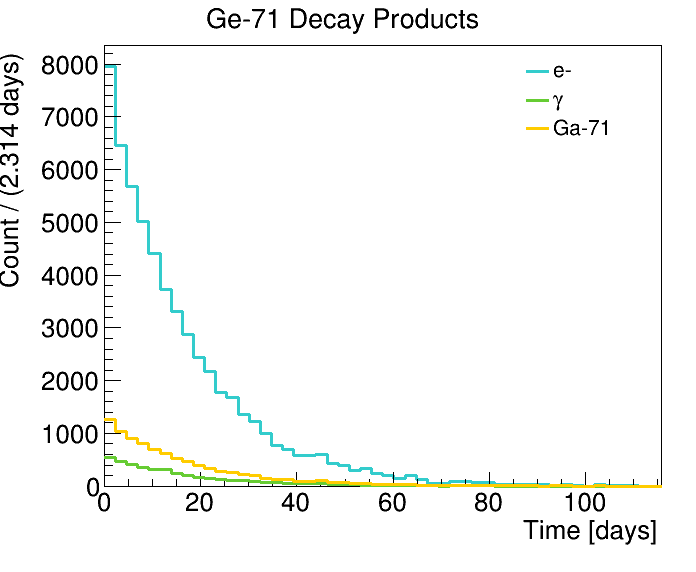

In [159]:
ROOT.gStyle.SetOptStat(0)
s2day = 1.157e-5
bins_start = 0
bins_end = 1e7*s2day
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Ge-71 Decay Products;Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data1 = Time_electron
custom_color1 = ROOT.TColor(1001, 16/255., 104/255., 218/255.)  # Normalize RGB to 0-1 range

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kCyan-3)


# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h3", f";Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data3 = Time_gamma
custom_color3 = ROOT.TColor(1003, 238/255., 195/255., 63/255.)  # Normalize RGB to 0-1 range

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kSpring-5)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h4 = ROOT.TH1F("h4", f";Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data4 = Time_Ga71
custom_color4 = ROOT.TColor(1004, 249/255., 249/255., 14/255.)  # Normalize RGB to 0-1 range

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(3)
h4.SetLineColor(ROOT.kOrange)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-30, 160)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.75, 0.75, 0.93, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "e-", "l")
legend.AddEntry(h3, "#gamma", "l")
legend.AddEntry(h4, "Ga-71", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
#h2.Draw("SAME")
h3.Draw("SAME")
h4.Draw("SAME")
legend.Draw()
c.Draw()

In [30]:
def func(x, a, b):
    return a*x + b

In [31]:
from scipy.optimize import curve_fit

counts_Ga71, bin_edges = np.histogram(Time_Ga71, bins = TimeBins)
bin_centers = bin_edges[:-1] + np.diff(TimeBins)[0] / 2

popt, pcov = curve_fit(func, bin_centers[:-7], np.log(counts_Ga71[:-7]), sigma=np.sqrt(counts_Ga71[:-7]) / counts_Ga71[:-7], absolute_sigma=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h4 (Potential memory leak).


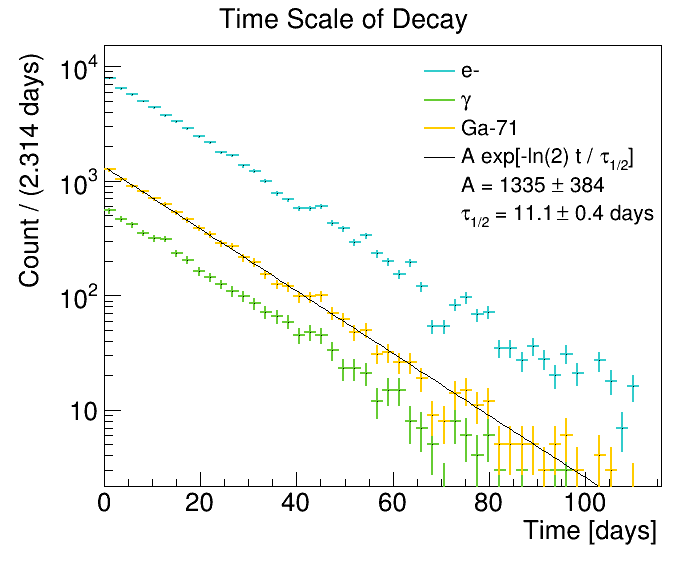

In [152]:
ROOT.gStyle.SetOptStat(0)
s2day = 1.157e-5
bins_start = 0
bins_end = 1e7*s2day
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Time Scale of Decay;Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data1 = Time_electron
custom_color1 = ROOT.TColor(1001, 16/255., 104/255., 218/255.)  # Normalize RGB to 0-1 range

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kCyan-3)


# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h3", f";Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data3 = Time_gamma
custom_color3 = ROOT.TColor(1003, 238/255., 195/255., 63/255.)  # Normalize RGB to 0-1 range

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(2)
h3.SetLineColor(ROOT.kSpring-5)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h4 = ROOT.TH1F("h4", f";Time [days];Count / ({bindiff} days)", nbins, bins_start, bins_end)
data4 = Time_Ga71
custom_color4 = ROOT.TColor(1004, 249/255., 249/255., 14/255.)  # Normalize RGB to 0-1 range

for value in data4:
    h4.Fill(value)
h4.SetLineWidth(2)
h4.SetLineColor(ROOT.kOrange)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-30, 160)

# Define the exponential function: A * exp(-lambda * x)
exp_func = ROOT.TF1("exp_func", "[0]*exp(-[1]*x)", 0, 500)
exp_func.SetParameters(np.exp(popt[1]), -popt[0])  # Initial guesses: amplitude, decay constant
exp_func.SetLineColor(ROOT.kBlack)
exp_func.SetLineWidth(1)
amplitude = np.exp(popt[1])
amplitude_err = np.exp(popt[1]) * np.sqrt(pcov[1][1]**2 + (popt[1] * 0.04)**2)
lifetime = -1/popt[0]
lifetime_err = 1/popt[0]**2 * np.sqrt((pcov[0][0])**2 + (popt[0] * 0.04)**2)
halflife = np.log(2) * lifetime
halflife_err = np.log(2) * lifetime_err

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.6, 0.6, 0.85, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "e-", "l")
legend.AddEntry(h3, "#gamma", "l")
legend.AddEntry(h4, "Ga-71", "l")
legend.AddEntry(exp_func, "A exp[-ln(2) t / #tau_{1/2}]", "l")
legend.AddEntry(0, f"A = {amplitude:.0f} #pm {amplitude_err:.0f}", "")
legend.AddEntry(0, '#tau_{1/2} = ' f"{halflife:.1f} #pm {halflife_err:.1f} days", "")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw('E0')
#h2.Draw("SAME")
h3.Draw("SAME E0")
h4.Draw("SAME E0")
exp_func.Draw("SAME")
legend.Draw()
c.SetLogy()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h3 (Potential memory leak).


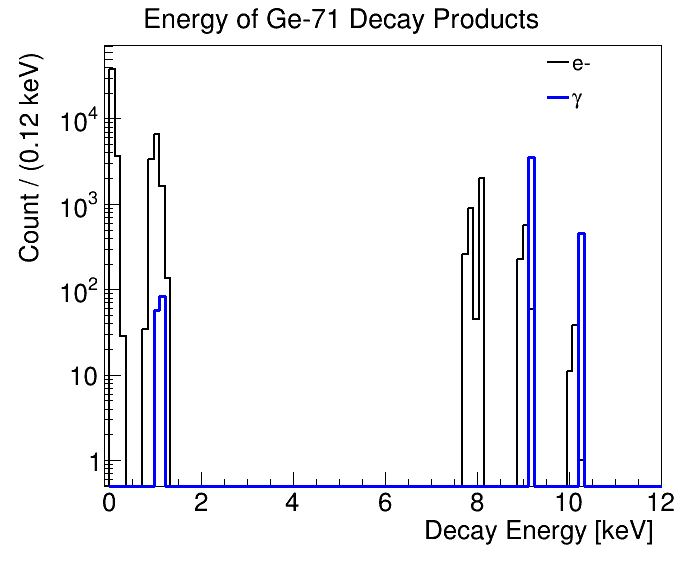

In [106]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Energy of Ge-71 Decay Products;Decay Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data1 = mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kBlack)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h3 = ROOT.TH1F("h3", f";Decay Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data3 = mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3

for value in data3:
    h3.Fill(value)
h3.SetLineWidth(3)
h3.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-3, 12)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.78, 0.8, 0.95, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "e-", "l")
legend.AddEntry(h3, "#gamma", "l")
legend.SetTextSize(0.04)

c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
#h2.Draw("SAME")
h3.Draw("SAME")
legend.Draw()
c.SetLogy()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).


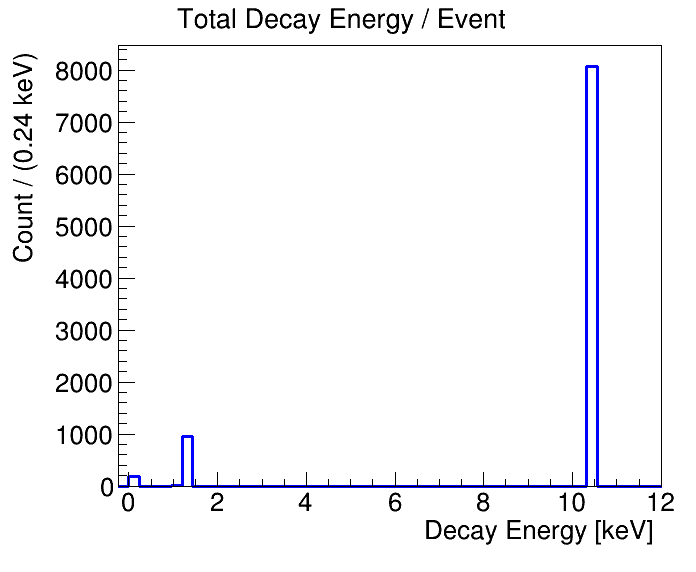

In [31]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Total Decay Energy / Event;Decay Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data1 = mcDecays['KEsum']*1e-3

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-4, 12)
#h1.SetTitleOffset(3)  # Move the main title up (if needed)

c.SetLeftMargin(0.17)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).


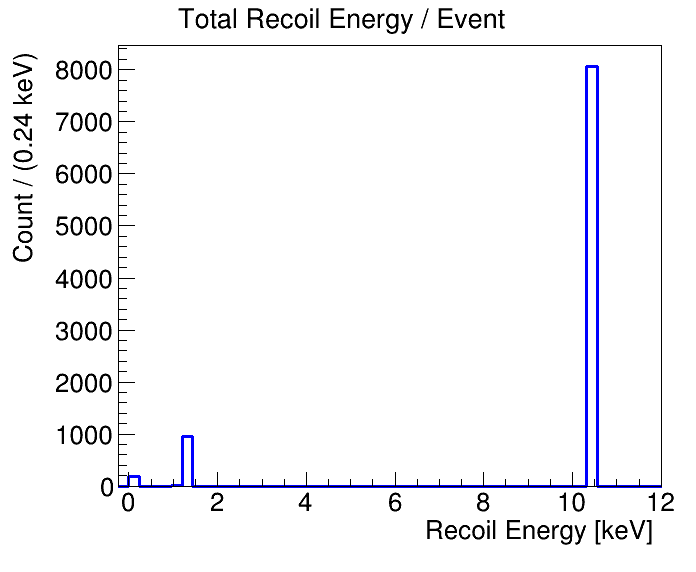

In [32]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Total Recoil Energy / Event;Recoil Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data1 = mczip['Edepsum']*1e-3

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-4, 12)
#h1.SetTitleOffset(3)  # Move the main title up (if needed)

c.SetLeftMargin(0.17)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).


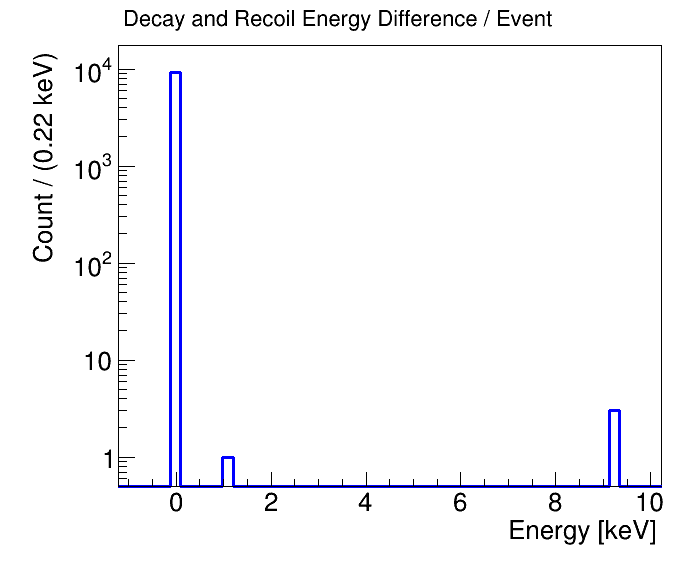

In [34]:
ROOT.gStyle.SetOptStat(0)
bins_start = -1
bins_end = 10
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", f"Decay and Recoil Energy Difference / Event;Energy [keV];Count / ({bindiff} keV)", nbins, bins_start, bins_end)
data1 = (mcDecays['KEsum']-mczip['Edepsum'])*1e-3

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-4, 12)
#h1.SetTitleOffset(3)  # Move the main title up (if needed)

c.SetLeftMargin(0.17)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
c.SetLogy()
c.Draw()

In [63]:
path = '/scratch/perry/SourceSimOutput_decayAncestor_Isotope/Cf252_vacuum/'
branches = ['EventNum', 'PName', 'KE', 'Edep', 'Time1', 'Time3']#, 'decayAncestor.PName', 'decayAncestor.Process']#, 
            #'decayAncestor.TrackID', 'decayAncestor.T', 'decayAncestor.VolName']
mcDecaysfiles = np.sort(glob.glob(path + f'Cf252_00250116_000000.root'))

In [64]:
mcDecaysFrame = CDataFrame(f"G4SimDir/mcDecays", mcDecaysfiles)
FissionEvents = np.unique(mcDecaysFrame.Filter('string(PName.data()) == "neutron"').AsNumpy(['EventNum'])['EventNum'])
mcDecays = mcDecaysFrame.AsNumpy(branches)

In [65]:
fourColors = ['blue', '#00BCBC', '#E59621', '#E50000']

In [66]:
eventMask = np.isin(mcDecays['EventNum'], FissionEvents)

In [67]:
#PNames = {event: mcDecays['PName'][mcDecays['EventNum'] == event] for event in np.unique(mcDecays['EventNum'])}
#KEs = {event: mcDecays['KE'][mcDecays['EventNum'] == event] for event in np.unique(mcDecays['EventNum'])}
PNamesFission = {event: mcDecays['PName'][mcDecays['EventNum'] == event] for event in FissionEvents}

In [68]:
n_emitted = np.zeros(len(list(PNamesFission.keys())))
for i, event in enumerate(list(PNamesFission.keys())):
    n_emitted[i] = PNamesFission[event].tolist().count('neutron')

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


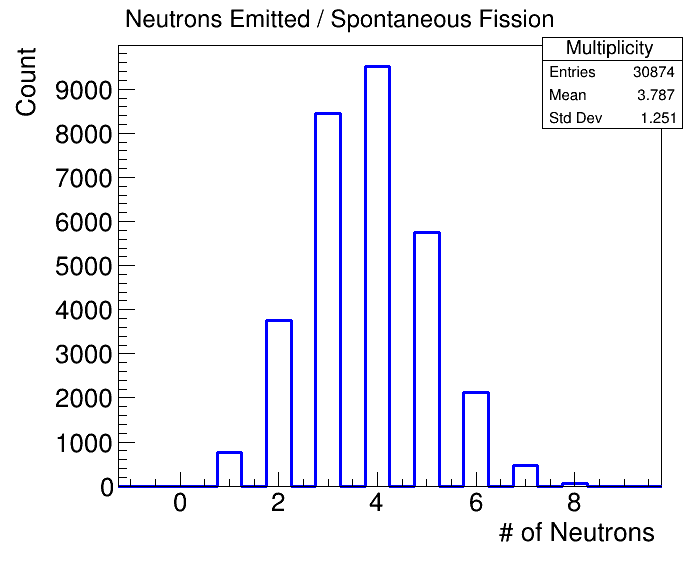

In [71]:
ROOT.gStyle.SetOptStat(1)
bins_start = -0.75
bins_end = 9.25
nbins = len(np.arange(-0.75, 9.25, 0.5))
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("Multiplicity", f"Neutrons Emitted / Spontaneous Fission;# of Neutrons;Count", nbins, bins_start, bins_end)
data1 = n_emitted

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-4, 12)
#h1.SetTitleOffset(3)  # Move the main title up (if needed)

c.SetLeftMargin(0.17)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: Multiplicity (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: inset_hist (Potential memory leak).


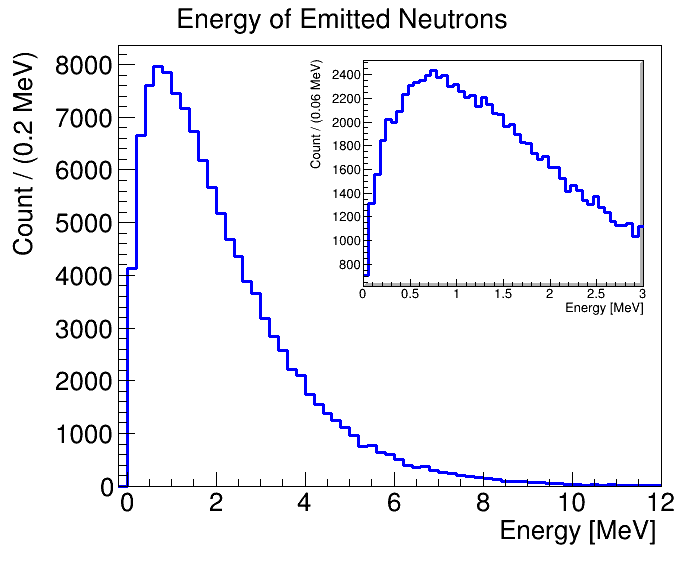

In [96]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 20
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("Multiplicity", f"Energy of Emitted Neutrons;Energy [MeV];Count / ({bindiff} MeV)", nbins, bins_start, bins_end)
data1 = mcDecays['KE'][mcDecays['PName'] == 'neutron']*1e-6

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
h1.GetXaxis().SetRangeUser(-4, 12)
h1.Draw()

# Create the inset histogram (for example, zoomed-in portion)
inset_hist = ROOT.TH1F("inset_hist", " ;Energy [MeV];Count / (0.06 MeV)", 50, 0, 3)
for value in data1:
    inset_hist.Fill(value)
inset_hist.SetLineWidth(3)
# Create a small inset pad (TPad)
# Define the position and size of the inset as (x1, y1, x2, y2), where values are between 0 and 1
inset_pad = ROOT.TPad("inset_pad", "Inset Pad", 0.42, 0.4, 0.93, 0.90)
#inset_pad.SetBorderSize(2)  # Optional: Set the border size of the inset
inset_pad.SetFillColor(0)   # Set background color of inset (0 means transparent)
inset_pad.Draw()  # Draw the inset pad on the main canvas
inset_pad.cd()  # Switch to the inset pad

# Draw the inset histogram (zoomed-in version)
inset_hist.SetLineColor(ROOT.kBlue)
inset_hist.GetXaxis().SetLabelSize(0.05)
inset_hist.GetYaxis().SetLabelSize(0.05)
inset_hist.GetXaxis().SetTitleSize(0.05)
inset_hist.GetYaxis().SetTitleSize(0.05)
inset_hist.Draw()

# Optionally, add a box around the inset plot to highlight it
inset_pad.SetFrameBorderSize(3)
inset_pad.SetFrameBorderMode(1)
# Adjust the margins of the inset pad
inset_pad.SetLeftMargin(0.2)    # Reduce left margin
inset_pad.SetRightMargin(0.01)   # Reduce right margin
inset_pad.SetTopMargin(0.01)     # Reduce top margin
inset_pad.SetBottomMargin(0.2)  # Reduce bottom margin

# Draw a border around the inset axis (optional)
#inset_pad.SetFrameFillColor(ROOT.kWhite)  # Set background of inset border
#inset_pad.SetFrameLineColor(ROOT.kBlack)


c.SetLeftMargin(0.17)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.Update()
c.Draw()